In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, auc, recall_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Functions

In [2]:
def round_half_up(arr):
    """Round each element of a NumPy array using half-up rounding."""
    return np.floor(arr + 0.5)

def compute_metrics(y_true, y_pred):
    """Compute accuracy, sensitivity (TPR), and specificity (TNR) for binary predictions."""
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    spec = recall_score(y_true, y_pred, pos_label=0)
    return acc, sens, spec

# Load data

In [3]:
data = pd.read_csv('./coc_data.csv')

In [4]:
drop_list = [
    'Quelle', # Data Source (Observational Data from SURGE-Ahead (SA), or Trauma Register (ATZ)
    'Entlassungdestination (Kategorie)', # Discharge destination (category)
    'Kreuz-Validierung (Fold)', # Cross-Validation (CV; folds). In order to prevent information spillover, folds used in EDA are kept for CV.
]

In [5]:
X = data.loc[data['Quelle'] == 'SA'].drop(drop_list, axis=1)
y = data.loc[data['Quelle'] == 'SA', 'Entlassungdestination (Kategorie)'].values # save as numpy array
y_geriatrics = (y == 1).astype(int)

# Analysis


## Original Model
The original predictor is an **AdaBoost model** with **12 estimators**. \
It serves as the baseline model from which the scoring system is derived. \
This model combines multiple weak learners to improve predictive performance while remaining interpretable.

In [6]:
# Stump 1
# Barthel Index am post-OP Tag 3 (Score, ordinal)
# Threshold: ≤ 52.5
# Weight 1.25
# Left Leave (True) [0.27 0.73]
# Right Leave (False) [0.88 0.12]

weight01 = 1.25
X['stump01'] = X['Barthel Index am post-OP Tag 3 (Score, ordinal)'] <= 52.5

# Stump 2
# Clinical Frailty Scale (Score, ordinal)
# Threshold: ≤ 4.5
# Weight 0.9
# Left Leave (True) [0.7 0.3]
# Right Leave (False) [0.27 0.73]

weight02 = 0.9
X['stump02'] = X['Clinical Frailty Scale (Score, ordinal)'] >= 4.5

# Stump 3
# Barthel-Index am post-OP Tag 1 (Score, ordinal)
# Threshold: ≤ 62.5
# Weight 0.61
# Left Leave (True) [0.41 0.59]
# Right Leave (False) [0.95 0.05]

weight03 = 0.61
X['stump03'] = X['Barthel-Index am post-OP Tag 1 (Score, ordinal)'] <= 62.5

# Stump 4
# Alter bei OP (Jahre)
# Threshold: ≤ 87.5
# Weight 0.79
# Left Leave (True) [0.67 0.33]
# Right Leave (False) [0.2 0.8]

weight04 = 0.79
X['stump04'] = X['Alter bei OP (Jahre)'] >= 87.5

# Stump 5
# Barthel-Index bei Aufnahme (Score, ordinal)
# Threshold: ≤ 67.5
# Weight 0.68
# Left Leave (True) [0.36 0.64]
# Right Leave (False) [0.75 0.25]

weight05 = 0.68
X['stump05'] = X['Barthel-Index bei Aufnahme (Score, ordinal)'] <= 67.5

# Stump 6
# Anzahl der Dauermedikamente (n)
# Threshold: ≤ 7.5
# Weight 0.62
# Left Leave (True) [0.72 0.28]
# Right Leave (False) [0.4 0.6]

weight06 = 0.62
X['stump06'] = X['Anzahl der Dauermedikamente (n)'] >= 7.5

# Stump 7
# Barthel Index am post-OP Tag 3 (Score, ordinal)
# Threshold: ≤ 42.5
# Weight 0.62
# Left Leave (True) [0.19 0.81]
# Right Leave (False) [0.62 0.38]

weight07 = 0.62
X['stump07'] = X['Barthel Index am post-OP Tag 3 (Score, ordinal)'] <= 42.5

# Stump 8
# Barthel-Index am post-OP Tag 1 (Score, ordinal)
# Threshold: ≤ 67.5
# Weight 0.42
# Left Leave (True) [0.42 0.58]
# Right Leave (False) [1. 0.]

weight08 = 0.42
X['stump08'] = X['Barthel-Index am post-OP Tag 1 (Score, ordinal)'] <= 67.5

# Stump 9
# Anzahl der Dauermedikamente (n)
# Threshold: ≤ 11.5
# Weight 0.44
# Left Leave (True) [0.59 0.41]
# Right Leave (False) [0.27 0.73]

weight09 = 0.44
X['stump09'] = X['Anzahl der Dauermedikamente (n)'] >= 11.5

# Stump 10
# Barthel-Index am post-OP Tag 1 (Score, ordinal)
# Threshold: ≤ 67.5
# Weight 0.33
# Left Leave (True) [0.44 0.56]
# Right Leave (False) [1. 0.]

weight10 = 0.33
X['stump10'] = X['Barthel-Index am post-OP Tag 1 (Score, ordinal)'] <= 67.5

# Stump 11
# Betreutes Wohnen (Ja/Nein)
# Threshold: ≤ 0.5
# Weight 0.37
# Left Leave (True) [0.57 0.43]
# Right Leave (False) [0.17 0.83]

weight11 = 0.37
X['stump11'] = X['Betreutes Wohnen (Ja/Nein)'] >= 0.5

# Stump 12
# ISAR (Score, ordinal)
# Threshold: ≤ 2.5
# Weight 0.46
# Left Leave (True) [0.62 0.38]
# Right Leave (False) [0.39 0.61]

weight12 = 0.46
X['stump12'] = X['ISAR (Score, ordinal)'] >= 2.5


## Scoring System
The scoring system is a **simplified, interpretable version of the original AdaBoost model**. Instead of using the full ensemble, it converts the model into a **weighted point system** based on the AdaBoost estimators (stumps).

**How it works:**
1. Each AdaBoost estimator (stump) has an associated **weight** from the trained model.
2. These weights are scaled by a factor and rounded to integers to create a simple additive scoring system.
3. The system is optimized by testing different numbers of stumps (`n_stumps`) and scaling factors (`f`) to **maximize the ROC AUC** on the training data.
4. The final scoring system uses the **best combination** of stumps and scaling factor, producing integer weights that are easy to apply in clinical practice.

This approach keeps the predictive power of AdaBoost while providing a **transparent and easy-to-use scoring system** for decision support.

In [7]:
# Collect weights from the trained AdaBoost model (12 estimators)
weights = np.array([globals()[f"weight{i:02d}"] for i in range(1, 13)])

# Factors to scale weights before rounding to integers
factors = np.arange(1.0, 3.1, 0.1)

# Variables to store the best results
best_auc = -np.inf
best_n_stumps = None
best_factor = None

# Iterate over number of stumps (1 to 12) to see how many contribute best
for n_stumps in range(1, 13):
    
    _best_auc = -np.inf
    _best_factor = None
    
    # Iterate over scaling factors to maximize AUC
    for f in factors:
        # Compute the integer-based score by scaling and rounding weights,
        # then multiplying by the corresponding stump values
        s = sum(
            round_half_up(f * weights[i - 1]) * X[f"stump{i:02d}"]
            for i in range(1, n_stumps + 1)
        )
        
        # Compute ROC AUC for this scoring system
        a = round(roc_auc_score(y_geriatrics, s), 2)
        
        # Update the best factor for this number of stumps
        if a > _best_auc:
            _best_auc = a
            _best_factor = f
    
    # Update global best AUC across all numbers of stumps
    if _best_auc > best_auc:
        best_auc = _best_auc
        best_n_stumps = n_stumps
        best_factor = _best_factor

# Print the final optimized scoring system parameters
print(f"Number of Stumps: {best_n_stumps}")
print(f"Best Factor: {best_factor:.2f}")
print(f"Best ROC AUC: {best_auc:.2f}")
print(f"Best integer weights: {round_half_up(best_factor * weights[:best_n_stumps])}")


Number of Stumps: 6
Best Factor: 1.20
Best ROC AUC: 0.92
Best integer weights: [2. 1. 1. 1. 1. 1.]


In [8]:
scoring_system = sum(
    round_half_up(best_factor * weights[i]) * X[f"stump{i+1:02d}"]
    for i in range(best_n_stumps)
)

## Results
The following metrics summarize the performance of the scoring system:

- **Accuracy, Sensitivity, and Specificity**: Reported for the **optimal cut-off** determined by the **Youden Index**, which balances true positive and true negative rates.
- **Receiver Operating Characteristic (ROC) curve**: Illustrates the model’s discriminative ability across all thresholds.

These results provide a clear overview of how well the scoring system distinguishes between patient outcomes.

In [9]:
# Compute Youden Index for each threshold
fpr, tpr, thresholds = roc_curve(y_geriatrics, scoring_system)
youden_index = tpr - fpr

# Find threshold that maximizes the Youden Index
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden Index): {optimal_threshold:.0f}")

# Apply optimal threshold to convert scores into binary predictions
y_pred_optimal = (scoring_system >= optimal_threshold).astype(int)

# Compute metrics on the original sample
accuracy, sensitivity, specificity = compute_metrics(y_geriatrics, y_pred_optimal)

# Bootstrapping for confidence intervals
n_bootstraps = 1000
rng_seed = 42
rng = np.random.RandomState(rng_seed)
boot_metrics = []

for i in range(n_bootstraps):
    # Resample indices with replacement
    indices = rng.randint(0, len(y_geriatrics), len(y_geriatrics))
    y_true_boot = y_geriatrics[indices]
    y_pred_boot = y_pred_optimal[indices]
    
    # Compute metrics on bootstrap sample
    boot_metrics.append(compute_metrics(y_true_boot, y_pred_boot))

boot_metrics = np.array(boot_metrics)

# Compute 2.5th and 97.5th percentiles for 95% CI
acc_ci = np.percentile(boot_metrics[:,0], [2.5, 97.5])
sens_ci = np.percentile(boot_metrics[:,1], [2.5, 97.5])
spec_ci = np.percentile(boot_metrics[:,2], [2.5, 97.5])

print(f"Accuracy:    {accuracy:.2f} (95% CI: {acc_ci[0]:.2f} - {acc_ci[1]:.2f})")
print(f"Sensitivity: {sensitivity:.2f} (95% CI: {sens_ci[0]:.2f} - {sens_ci[1]:.2f})")
print(f"Specificity: {specificity:.2f} (95% CI: {spec_ci[0]:.2f} - {spec_ci[1]:.2f})")


Optimal threshold (Youden Index): 4
Accuracy:    0.84 (95% CI: 0.79 - 0.89)
Sensitivity: 0.89 (95% CI: 0.82 - 0.96)
Specificity: 0.80 (95% CI: 0.72 - 0.88)


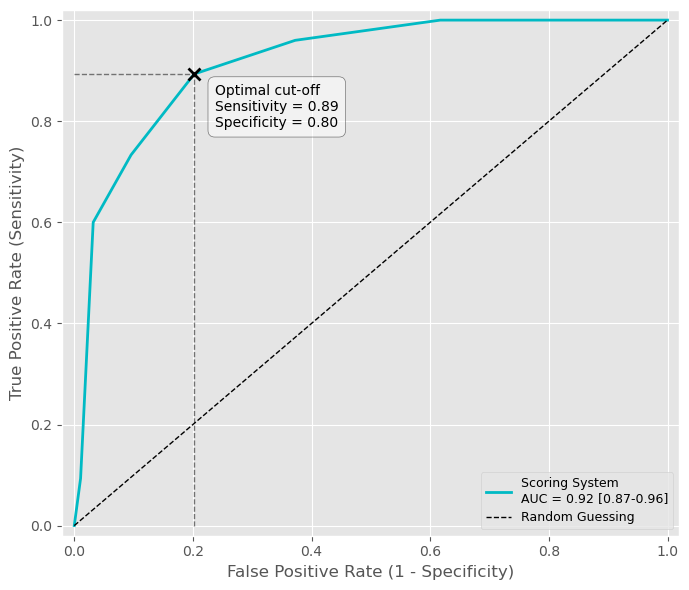

In [10]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(7, 6))  # create axis object

# Compute ROC curve values and the Area Under the Curve (AUC)
fpr, tpr, thresholds = roc_curve(y_geriatrics, scoring_system)
roc_auc = auc(fpr, tpr)

# Compute 95% confidence interval for AUC (bootstrap example)
n_bootstraps = 1000
rng_seed = 42
rng = np.random.RandomState(rng_seed)
bootstrapped_scores = []

for i in range(n_bootstraps):
    indices = rng.randint(0, len(scoring_system), len(scoring_system))
    if len(np.unique(y_geriatrics[indices])) < 2:
        continue
    score = auc(*roc_curve(y_geriatrics[indices], scoring_system[indices])[:2])
    bootstrapped_scores.append(score)

ci_lower = np.percentile(bootstrapped_scores, 2.5)
ci_upper = np.percentile(bootstrapped_scores, 97.5)

# Plot ROC curve
ax.plot(fpr, tpr, color='#00BAC4', lw=2,
        label=f"Scoring System\nAUC = {roc_auc:.2f} [{ci_lower:.2f}-{ci_upper:.2f}]")

# Get optimal threshold index from previous cell
optimal_idx = np.argmax(tpr - fpr)
opt_fpr = fpr[optimal_idx]
opt_tpr = tpr[optimal_idx]

# Sensitivity and specificity
sens = opt_tpr
spec = 1 - opt_fpr

# Draw horizontal and vertical lines
ax.plot([0, opt_fpr], [opt_tpr, opt_tpr], 'k--', linewidth=1, alpha=0.5, label='_nolegend_')
ax.plot([opt_fpr, opt_fpr], [0, opt_tpr], 'k--', linewidth=1, alpha=0.5, label='_nolegend_')

# Mark optimal point
ax.plot(opt_fpr, opt_tpr, 'x', color='black', markersize=8, markeredgewidth=2, markerfacecolor='black', label='_nolegend_')
ax.annotate(
    f'Optimal cut-off\nSensitivity = {sens:.2f}\nSpecificity = {spec:.2f}',
    xy=(opt_fpr, opt_tpr),
    xytext=(opt_fpr + 0.035, opt_tpr - 0.105),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.5)
)

# Plot diagonal line for random guessing
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')

# Labels and legend
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend(fontsize=9, loc='lower right')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Show and save
plt.tight_layout()
plt.savefig('ROC_scoring_system.png', bbox_inches='tight', dpi=400)
plt.show()


# Simpler Models
Typically, patients only show improvement after surgery, unless a complication arises. In cases of complications, additional surgical interventions are usually required, so discharge is not relevant, and the algorithm must be applied following the second surgery. Therefore, we can remove the day 1 post-operative Barthel Index ≤60 from the scoring system and instead increase the weight of the day 3 Barthel Index by 1.

In [11]:
# The simpler scoring system removes stump03 - Barthel Index at post-OP day 1
simple_scoring_system = 3*X['stump01'] + X['stump02'] + X['stump04'] + X['stump05'] + X['stump06'] 

In [12]:
# Compute Youden Index for each threshold
fpr, tpr, thresholds = roc_curve(y_geriatrics, simple_scoring_system)
youden_index = tpr - fpr

# Find threshold that maximizes the Youden Index
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden Index): {optimal_threshold:.0f}")

# Apply optimal threshold to convert scores into binary predictions
y_pred_optimal = (simple_scoring_system >= optimal_threshold).astype(int)

# Compute metrics on the original sample
accuracy, sensitivity, specificity = compute_metrics(y_geriatrics, y_pred_optimal)

# Bootstrapping for confidence intervals
n_bootstraps = 1000
rng_seed = 42
rng = np.random.RandomState(rng_seed)
boot_metrics = []

for i in range(n_bootstraps):
    # Resample indices with replacement
    indices = rng.randint(0, len(y_geriatrics), len(y_geriatrics))
    y_true_boot = y_geriatrics[indices]
    y_pred_boot = y_pred_optimal[indices]
    
    # Compute metrics on bootstrap sample
    boot_metrics.append(compute_metrics(y_true_boot, y_pred_boot))

boot_metrics = np.array(boot_metrics)

# Compute 2.5th and 97.5th percentiles for 95% CI
acc_ci = np.percentile(boot_metrics[:,0], [2.5, 97.5])
sens_ci = np.percentile(boot_metrics[:,1], [2.5, 97.5])
spec_ci = np.percentile(boot_metrics[:,2], [2.5, 97.5])

print(f"Accuracy:    {accuracy:.2f} (95% CI: {acc_ci[0]:.2f} - {acc_ci[1]:.2f})")
print(f"Sensitivity: {sensitivity:.2f} (95% CI: {sens_ci[0]:.2f} - {sens_ci[1]:.2f})")
print(f"Specificity: {specificity:.2f} (95% CI: {spec_ci[0]:.2f} - {spec_ci[1]:.2f})")


Optimal threshold (Youden Index): 4
Accuracy:    0.86 (95% CI: 0.80 - 0.91)
Sensitivity: 0.85 (95% CI: 0.76 - 0.94)
Specificity: 0.86 (95% CI: 0.79 - 0.93)


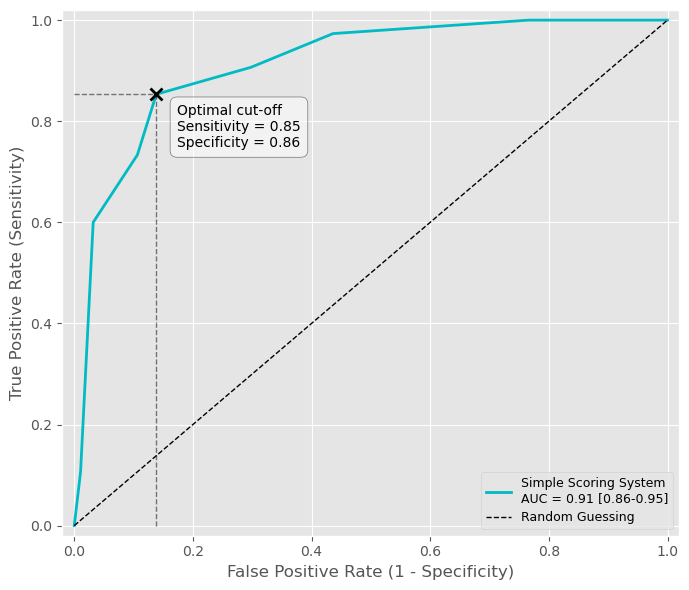

In [13]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(7, 6))  # create axis object

# Compute ROC curve values and the Area Under the Curve (AUC)
fpr, tpr, thresholds = roc_curve(y_geriatrics, simple_scoring_system)
roc_auc = auc(fpr, tpr)

# Compute 95% confidence interval for AUC (bootstrap example)
n_bootstraps = 1000
rng_seed = 42
rng = np.random.RandomState(rng_seed)
bootstrapped_scores = []

for i in range(n_bootstraps):
    indices = rng.randint(0, len(simple_scoring_system), len(simple_scoring_system))
    if len(np.unique(y_geriatrics[indices])) < 2:
        continue
    score = auc(*roc_curve(y_geriatrics[indices], simple_scoring_system[indices])[:2])
    bootstrapped_scores.append(score)

ci_lower = np.percentile(bootstrapped_scores, 2.5)
ci_upper = np.percentile(bootstrapped_scores, 97.5)

# Plot ROC curve
ax.plot(fpr, tpr, color='#00BAC4', lw=2,
        label=f"Simple Scoring System\nAUC = {roc_auc:.2f} [{ci_lower:.2f}-{ci_upper:.2f}]")

# Get optimal threshold index from previous cell
optimal_idx = np.argmax(tpr - fpr)
opt_fpr = fpr[optimal_idx]
opt_tpr = tpr[optimal_idx]

# Sensitivity and specificity
sens = opt_tpr
spec = 1 - opt_fpr

# Draw horizontal and vertical lines
ax.plot([0, opt_fpr], [opt_tpr, opt_tpr], 'k--', linewidth=1, alpha=0.5, label='_nolegend_')
ax.plot([opt_fpr, opt_fpr], [0, opt_tpr], 'k--', linewidth=1, alpha=0.5, label='_nolegend_')

# Mark optimal point
ax.plot(opt_fpr, opt_tpr, 'x', color='black', markersize=8, markeredgewidth=2, markerfacecolor='black', label='_nolegend_')
ax.annotate(
    f'Optimal cut-off\nSensitivity = {sens:.2f}\nSpecificity = {spec:.2f}',
    xy=(opt_fpr, opt_tpr),
    xytext=(opt_fpr + 0.035, opt_tpr - 0.105),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.5)
)

# Plot diagonal line for random guessing
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')

# Labels and legend
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend(fontsize=9, loc='lower right')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Show and save
plt.tight_layout()
plt.savefig('ROC_simple_scoring_system.png', bbox_inches='tight', dpi=400)
plt.show()
